# P2: Ley de Zipf
Veremos si un idioma artificial creado aleatoreamente cumple con la ley de Pzif, y veremos como se comporta una lengua con pocos recursos digitales.

In [1]:
# Importamos las librerías necesarias
import pdfplumber
import re
import numpy as np
import pandas as pd
from collections import Counter
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import os

## Procesamiento de texto

In [2]:
def limpia_pdf(pdf_path):
    texto = ""
    with pdfplumber.open(pdf_path) as pdf:
        for pagina in pdf.pages:
            texto += pagina.extract_text() + "\n"
    texto = texto.lower()
    texto = re.sub(r"\d+", "", texto)
    texto = re.sub(r"[^\w\s']", " ", texto)
    return texto.split()

def contar_palabras(texto):
    conteo = Counter(texto)
    return conteo

def crear_dataframe(conteo):
    df = pd.DataFrame(conteo.items(), columns = ["Palabras","Frecuencia"])
    df = df.sort_values("Frecuencia", ascending = False,).copy()
    df["Rango"] = range(1,len(df)+1)
    return df

## Generando un idioma artificial.

In [3]:
# Definimos el alfabeto y la longitud de las palabras (con un espacio)
alfabeto = "abcdefghijklmnñopqrstuvwxyz "
letras_sueltas = np.random.choice(list(alfabeto), size=5000000, replace=True)
chorizo_de_letras = "".join(letras_sueltas)
texto_artificial = chorizo_de_letras.split()

In [4]:
# Longitud de nuestro texto artificial, 
len(texto_artificial)

172768

## procesamos el texto artificial y analizamos su distribución de palabras.

In [5]:
conteo_artificial = contar_palabras(texto_artificial)
df = crear_dataframe(conteo_artificial)
df.head(15)

,Palabras,Frecuencia,Rango
1392,p,274,1
887,y,269,2
51,d,262,3
673,z,257,4
1192,g,250,5
231,a,250,6
55,m,245,7
1462,n,244,8
174,o,239,9
976,e,238,10


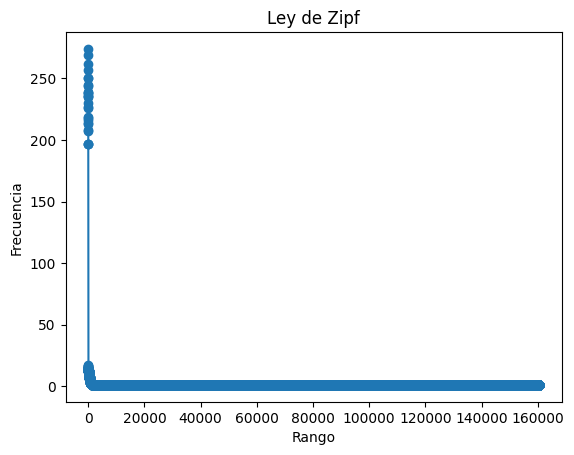

In [6]:
plt.plot(df["Rango"],df["Frecuencia"],marker = "o")
plt.title("Ley de Zipf")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.show()

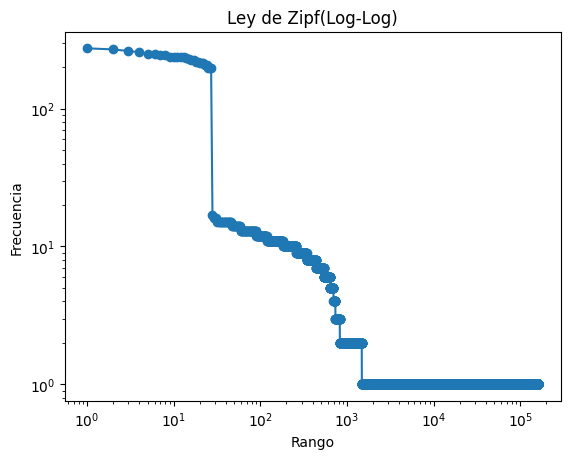

In [7]:
plt.loglog(df["Rango"], df["Frecuencia"], marker="o")
plt.title("Ley de Zipf(Log-Log)")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.show()

## Estimando el parametro alfa (usando el notebook de clase)

In [8]:
ranks = np.array(df["Rango"])
frequencies = np.array(df["Frecuencia"])

In [9]:
def zipf_minimization_objective(
    alpha: np.float64, word_ranks: np.ndarray, word_frequencies: np.ndarray
) -> np.float64:
    predicted_log_freq = np.log(word_frequencies[0]) -alpha * np.log(word_ranks)
    return np.sum((np.log(word_frequencies) - predicted_log_freq) ** 2)

In [10]:
initial_alpha_guess = 1.0

optimization_result = minimize(
    zipf_minimization_objective,
    initial_alpha_guess,
    args=(ranks, frequencies)
)

estimated_alpha = optimization_result.x[0]

mean_squared_error = zipf_minimization_objective(
    estimated_alpha, ranks, frequencies
)

print(f"Estimated alpha: {estimated_alpha:.4f}")
print(f"Mean Squared Error: {mean_squared_error:.4f}")

Estimated alpha: 0.5061
Mean Squared Error: 34145.0377


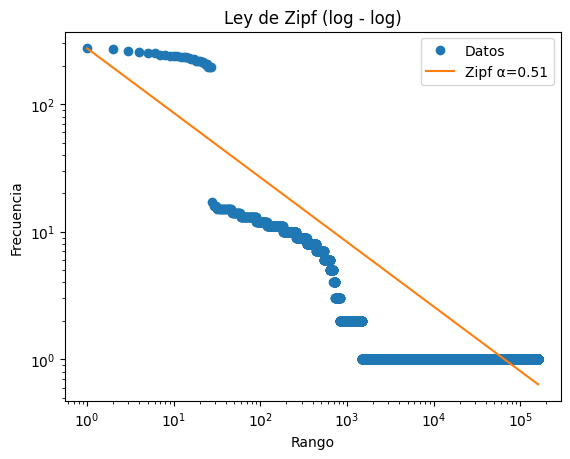

In [11]:
plt.loglog(ranks, frequencies, "o", label="Datos")

zipf_fit = frequencies[0] * ranks**(-estimated_alpha)

plt.loglog(ranks, zipf_fit, label=f"Zipf α={estimated_alpha:.2f}")

plt.title("Ley de Zipf (log - log)")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

## ¿Se aproxima a la ley de Zipf?
No, podemos ver que la curva no se ajusta a los datos (log-log) y que el parametro alfa no está cerca de ser 1 como pasa en los lenguajes naturales, asi que nuestro texto aleatorio no sigue la ley de Zipf

## Analizando un corpus con pocos recursos digitales
Analizaremos una biblia de Tzotzil de los altos de chiapas, exáctamente del Tzotzil de Zinacantán.

In [12]:
biblia_tzotzil = limpia_pdf("biblia_tzotzil.pdf")
conteo_tzo = contar_palabras(biblia_tzotzil)
df_tzo = crear_dataframe(conteo_tzo)

In [13]:
# DataFrame ordenado 
df_tzo.head(20)

,Palabras,Frecuencia,Rango
0,ti,39490,1
133,ta,24887,2
222,jech,8456,3
107,laj,6574,4
119,jaꞌ,4937,5
3,yuꞌun,4445,6
281,mu,2503,7
218,tey,2302,8
328,diose,2196,9
256,oy,2154,10


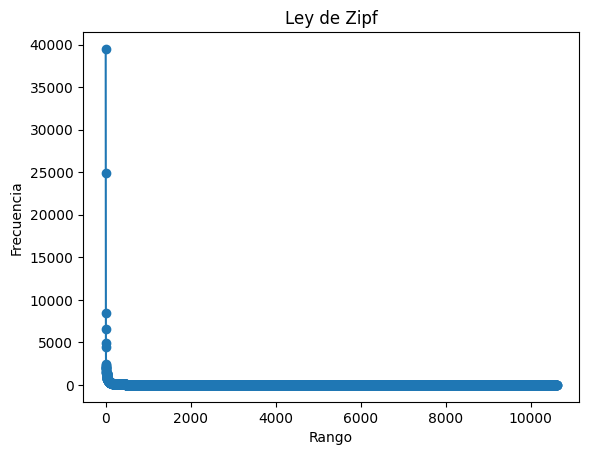

In [14]:
plt.plot(df_tzo["Rango"],df_tzo["Frecuencia"],marker = "o")
plt.title("Ley de Zipf")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.show()

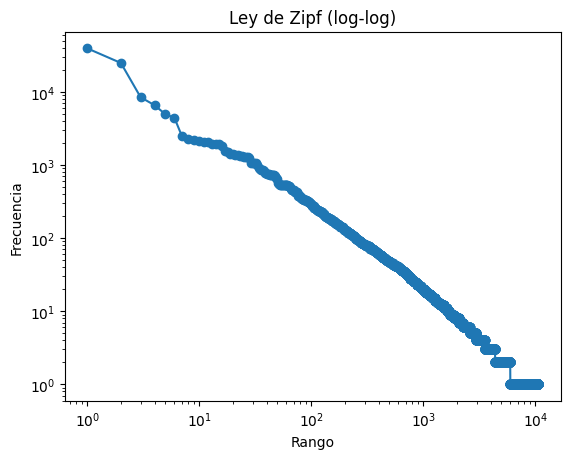

In [15]:
plt.loglog(df_tzo["Rango"],df_tzo["Frecuencia"],marker = "o")
plt.title("Ley de Zipf (log-log)")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.show()

In [16]:
ranks = np.array(df_tzo["Rango"])
frequencies = np.array(df_tzo["Frecuencia"])
initial_alpha_guess = 1.0

optimization_result = minimize(
    zipf_minimization_objective,
    initial_alpha_guess,
    args=(ranks, frequencies)
)

estimated_alpha = optimization_result.x[0]

mean_squared_error = zipf_minimization_objective(
    estimated_alpha, ranks, frequencies
)

print(f"Estimated alpha: {estimated_alpha:.4f}")
print(f"Mean Squared Error: {mean_squared_error:.4f}")

Estimated alpha: 1.1547
Mean Squared Error: 681.0885


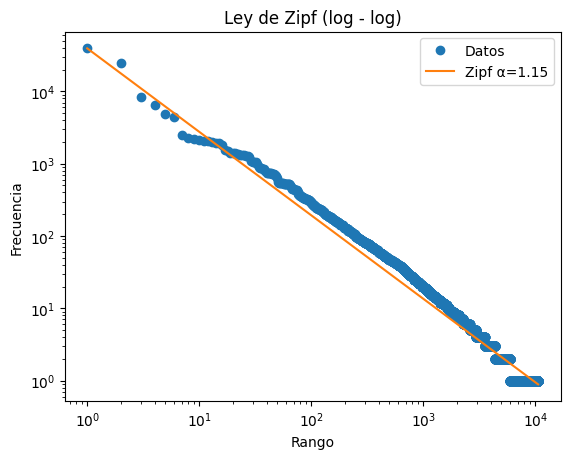

In [17]:
plt.loglog(ranks, frequencies, "o", label="Datos")

zipf_fit = frequencies[0] * ranks**(-estimated_alpha)

plt.loglog(ranks, zipf_fit, label=f"Zipf α={estimated_alpha:.2f}")

plt.title("Ley de Zipf (log - log)")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

### ¿Se aproxima a la ley de Zipf?
Si, notemos que la gŕafica logaritmica se acerca mucho a la recta generada por el alfa calculada anteriormente, al ser el Tzotzil una lengua natural claramente sigue la ley de Zipf.

## 2. Visualizando la diversidad linguistica de México y Chile
Reutilizaremos el código visto en clase.

In [18]:
DATA_PATH = "data"
LANG_GEO_FILE = "languages_and_dialects_geo.csv"
LANGUOID_FILE = "languoid.csv"

In [19]:
languages = pd.read_csv(os.path.join(DATA_PATH, LANG_GEO_FILE))
languoids = pd.read_csv(os.path.join(DATA_PATH, LANGUOID_FILE))

In [20]:
languages.head(15)
languoids.head(15)

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
0,3adt1234,afro1255,nort3292,3Ad-Tekles,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
1,aala1237,aust1307,ramo1244,Aalawa,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
2,aant1238,nucl1709,nort2920,Aantantara,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
3,aari1238,sout2845,ahkk1235,Aari-Gayil,False,family,NaN,NaN,aiz,NaN,NaN,0,2,0,NaN
4,aari1239,sout2845,aari1238,Aari,False,language,5.95034,36.5721,aiw,NaN,NaN,0,0,0,ET
5,aari1240,book1242,book1242,Aariya,True,language,NaN,NaN,aay,NaN,NaN,0,0,0,IN
6,aasa1238,afro1255,sout3054,Aasax,False,language,-4.00679,36.8648,aas,NaN,NaN,0,0,0,TZ
7,aasd1234,indo1319,ferr1240,Aasdring,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
8,aata1238,nucl1709,sout2943,Aatasaara,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
9,abaa1238,sino1245,nort3305,Rngaba,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN


In [21]:
min_lat = -14
max_lat = 33
min_long = -118
max_long = -86

mexico_languages = languages[
    (languages["latitude"] >= min_lat)
    &(languages["latitude"] <= max_lat)
    &(languages["longitude"] >= min_long)
    &(languages["longitude"] <= max_long)
]

In [22]:
len(mexico_languages)

427

### Tomamos la funcion de reconstruir linajes de la práctica

In [23]:
# Reconstrucción de linajes usando grafos locales (languoid.csv)
languoids_dict = languoids.set_index("id").to_dict("index")


def reconstruir_linaje(glottocode):
    """Sube por el árbol genealógico desde la lengua hasta la familia raíz."""
    linaje = []
    current_id = glottocode

    # Mientras el ID actual exista y no sea nulo (NaN)
    while pd.notna(current_id) and current_id in languoids_dict:
        nodo = languoids_dict[current_id]

        # Filtramos lenguas artificiales o "bookkeeping"
        if nodo.get("bookkeeping") or nodo.get("name") == "Unclassifiable":
            return "Unclassifiable"

        # Insertamos el nombre al inicio de la lista para mantener el orden (Raíz -> Lengua)
        linaje.insert(0, str(nodo["name"]))

        # Subimos al nodo padre
        current_id = nodo["parent_id"]

    return " > ".join(linaje)

In [24]:
mexico_languages = mexico_languages.copy()

mexico_languages["tree"] = mexico_languages["glottocode"].apply(reconstruir_linaje)

In [25]:
df_mexico = mexico_languages[
    ~mexico_languages["tree"].isin(["", "Unclassifiable"])
].copy()

In [28]:
df_mexico["Family"] = df_mexico["tree"].str.split().str[0]

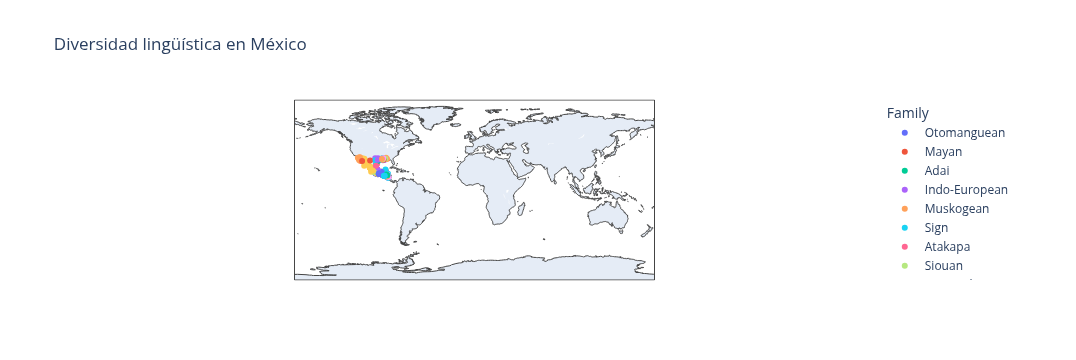

In [29]:
import plotly.express as px

fig = px.scatter_geo(
    df_mexico,
    lat="latitude",
    lon="longitude",
    color="Family",
    hover_name="name",
    title="Diversidad lingüística en México"
)

fig.show()

## Hacemos exactamente lo mismo para otro país, elegiremos Perú.


In [30]:
min_lat = -18
max_lat = 0
min_long = -82
max_long = -68

peru_languages = languages[
    (languages["latitude"] >= min_lat)
    & (languages["latitude"] <= max_lat)
    & (languages["longitude"] >= min_long)
    & (languages["longitude"] <= max_long)
]

In [31]:
peru_languages = peru_languages.copy()
peru_languages["tree"] = peru_languages["glottocode"].apply(reconstruir_linaje)
df_peru = peru_languages[
    ~peru_languages["tree"].isin(["", "Unclassifiable"])
].copy()
df_peru["Family"] = df_peru["tree"].str.split().str[0]

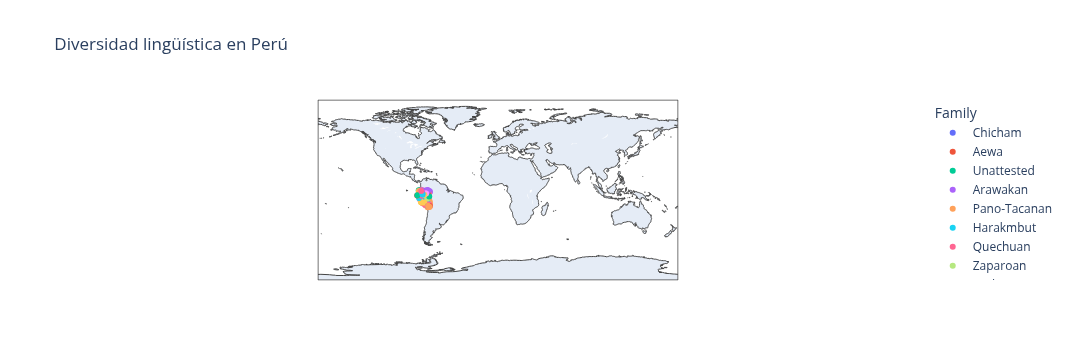

In [32]:
# Visualización de la diversidad lingüística en Perú
fig = px.scatter_geo(
    df_peru,
    lat="latitude",
    lon="longitude",
    color="Family",
    hover_name="name",
    title="Diversidad lingüística en Perú"
)
fig.show()

### Diversidad lingüistica de México en comparacion a Perú
Notemos la longitud de lenguajes en nuestras regiones

In [33]:
len(df_mexico)

404

In [34]:
len(df_peru)

177

In [35]:
df_mexico["Family"].nunique()

36

In [36]:
df_peru["Family"].nunique()

37

Diversidad lingüística en México con respecto a Perú

México presenta una mayor cantidad de lenguas en comparación con Perú (404 frente a 177), lo que indica una alta diversidad en términos absolutos. Sin embargo, el número de familias lingüísticas es muy similar entre ambos países (36 en México y 37 en Perú), lo que sugiere que, aunque México tiene más lenguas, estas están distribuidas en un número comparable de familias.

In [37]:
df_mexico["Family"].value_counts()

Family
Otomanguean                213
Uto-Aztecan                 54
Mayan                       36
Mixe-Zoque                  19
Totonacan                   13
Sign                        12
Cochimi-Yuman                8
Indo-European                5
Xincan                       5
Muskogean                    4
Huavean                      4
Tequistlatecan               3
Misumalpan                   2
Lencan                       2
Tarascan                     2
Jicaquean                    2
Adai                         1
Atakapa                      1
Siouan                       1
Chitimacha                   1
Coahuilteco                  1
Comecrudan                   1
Cotoname                     1
Cuitlatec                    1
Arawakan                     1
Guaicurian                   1
Unattested                   1
Karankawa                    1
Caddoan                      1
Athabaskan-Eyak-Tlingit      1
Maratino                     1
Pidgin                       1
N

### ¿Dónde se encuentra la mayor diversidad lingüistica en méxico? 
Zonas de mayor diversidad en México

La mayor diversidad lingüística en México se concentra en el sur y centro del país, particularmente en estados como Oaxaca, Chiapas, Guerrero y Veracruz. Esto se refleja en la alta presencia de lenguas pertenecientes a familias como la otomangue, la uto-azteca y la maya, siendo la familia otomangue la más dominante con una diferencia considerable respecto a las demás.